<a href="https://colab.research.google.com/github/ryanaxiom/Applied-ML/blob/main/code/Day15_Carnegie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Student Instructions**: Before you begin, click **File > Save a copy in Drive** so you do not lose your work!

In [2]:
url = ("https://raw.githubusercontent.com/ryanaxiom/Applied-ML/main/data/carnegie_data.csv")

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import KFold, cross_val_predict
carnegie_raw = pd.read_csv(url, encoding="cp1252")
carnegie = carnegie_raw.copy()
carnegie["research"] = carnegie["serd"] + carnegie["nonserd"]
d = carnegie[carnegie["research"].notna()].copy()
d["med_yn"] = (d["medical"] == 1).astype(int)
y = d["research"]
def rmse(a, b): return np.sqrt(np.mean((a - b)**2))
kf = KFold(n_splits=5, shuffle=True, random_state=309)
cands = ["fallenr20", "fallfte20", "ugtenr20", "grtenr20", "totdeg",
         "docrsdeg", "stem_rsd", "socsc_rsd", "hum_rsd", "oth_rsd",
         "facnum", "pdnfrstaff", "rooms", "numcip2", "pctadmitf20",
         "med_yn"]
d.shape, len(cands)

((302, 103), 16)

In [3]:
ols = LinearRegression()
ols.fit(d[cands], y)
ridge = Ridge(alpha=100)                 # raw columns, no scaler
ridge.fit(d[cands], y)
ratio = pd.Series(ridge.coef_ / ols.coef_, index=cands)
show = ["fallenr20", "facnum", "pctadmitf20", "med_yn"]
print(ratio[show].round(2))

fallenr20      0.88
facnum         1.00
pctadmitf20    0.10
med_yn         0.23
dtype: float64


In [6]:
scaled_all = StandardScaler().fit_transform(d[cands])  # all rows
pipe_s = make_pipeline(StandardScaler(), Ridge(alpha=10))
ridge = Ridge(alpha=10)
oof_none = cross_val_predict(ridge, d[cands], y, cv=kf)
oof_in = cross_val_predict(pipe_s, d[cands], y, cv=kf)
oof_leak = cross_val_predict(ridge, scaled_all, y, cv=kf)
for oof in [oof_none, oof_in, oof_leak]:
    print(round(rmse(y, oof)))

235363
224489
217622


In [7]:
alphas = np.logspace(-2, 4, 25)      # 0.01 to 10,000, log-spaced
cv = []
for a in alphas:
    pipe = make_pipeline(StandardScaler(), Ridge(alpha=a))
    oof = cross_val_predict(pipe, d[cands], y, cv=kf)
    cv.append(rmse(y, oof))
i = int(np.argmin(cv))
print(alphas[i], round(cv[i]), round(cv[0]), round(cv[-1]))

100.0 204894 235014 345891


In [8]:
np.logspace(-2, 4, 25)      # 0.01 to 10,000, log-spaced

array([1.00000000e-02, 1.77827941e-02, 3.16227766e-02, 5.62341325e-02,
       1.00000000e-01, 1.77827941e-01, 3.16227766e-01, 5.62341325e-01,
       1.00000000e+00, 1.77827941e+00, 3.16227766e+00, 5.62341325e+00,
       1.00000000e+01, 1.77827941e+01, 3.16227766e+01, 5.62341325e+01,
       1.00000000e+02, 1.77827941e+02, 3.16227766e+02, 5.62341325e+02,
       1.00000000e+03, 1.77827941e+03, 3.16227766e+03, 5.62341325e+03,
       1.00000000e+04])

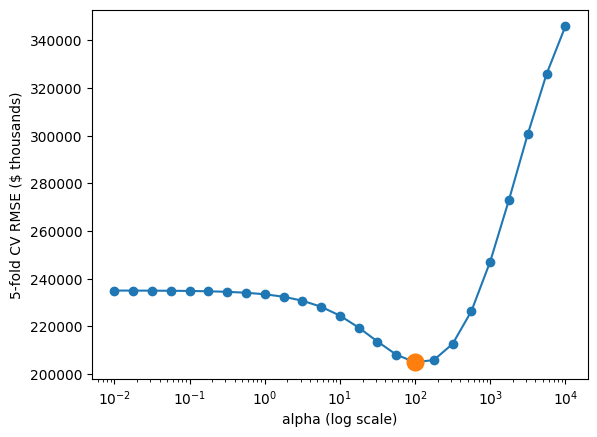

In [9]:
import matplotlib.pyplot as plt
plt.semilogx(alphas, cv, marker="o")
plt.plot(alphas[i], cv[i], "o", markersize=12)
plt.xlabel("alpha (log scale)")
plt.ylabel("5-fold CV RMSE ($ thousands)")
plt.show()

In [11]:
ols_s = make_pipeline(StandardScaler(), LinearRegression())
ols_s.fit(d[cands], y)
ridge_s = make_pipeline(StandardScaler(), Ridge(alpha=100))
ridge_s.fit(d[cands], y)
coefs = pd.DataFrame({"ols": ols_s[-1].coef_,
                      "ridge": ridge_s[-1].coef_}, index=cands)
twins = ["stem_rsd", "docrsdeg", "facnum"]
print(coefs.loc[twins].round().astype(int))
print(np.abs(coefs).sum().round().astype(int))

              ols  ridge
stem_rsd  3442672  70309
docrsdeg -5143381  43254
facnum     170688  98933
ols      11948655
ridge      471490
dtype: int64


In [12]:
from sklearn.model_selection import cross_val_score, GridSearchCV
pipe = make_pipeline(StandardScaler(), Ridge())
grid = {"ridge__alpha": np.logspace(-2, 4, 25)}
search = GridSearchCV(pipe, grid, cv=kf,
                      scoring="neg_mean_squared_error")
search.fit(d[cands], y)
print(search.best_params_["ridge__alpha"],
      round(np.sqrt(-search.best_score_)))
honest = cross_val_score(search, d[cands], y, cv=kf,
                         scoring="neg_mean_squared_error")
print(round(np.sqrt(-honest.mean())))

100.0 205093
215521


In [13]:
ols = LinearRegression()
ols.fit(d[cands], y)
best = make_pipeline(StandardScaler(), Ridge(alpha=100))
best.fit(d[cands], y)
print(round(rmse(y, ols.predict(d[cands]))),
      round(rmse(y, best.predict(d[cands]))))
mit = d[d["name"] == "Massachusetts Institute of Technology"]
actual = int(mit["research"].iloc[0])
print(actual, round(ols.predict(mit[cands])[0]),
      round(best.predict(mit[cands])[0]))

165237 176546
987968 983181 822153


In [14]:
pile = ["fallenr20", "totdeg", "facnum", "stem_rsd", "med_yn"]
truth = LinearRegression()
truth.fit(d[pile], y)
f = truth.predict(d[pile])                # the truth, known
rng = np.random.default_rng(309)
preds = np.zeros((len(alphas), 200, len(f)))
for w in range(200):                      # 200 worlds
    y_w = f + (y - f) * rng.choice([-1, 1], len(f))  # +/- the miss
    for j, a in enumerate(alphas):
        m = make_pipeline(StandardScaler(), Ridge(alpha=a))
        m.fit(d[cands], y_w)
        preds[j, w] = m.predict(d[cands])
bias2 = ((preds.mean(axis=1) - f)**2).mean(axis=1)
var = preds.var(axis=1).mean(axis=1)
j = int(np.argmin(bias2 + var))
print(alphas[j].round(1), np.sqrt([bias2[j], var[j]]).round())

17.8 [22601. 57190.]


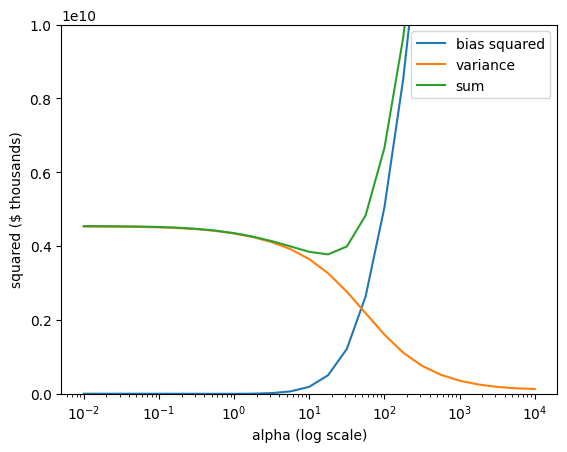

In [15]:
plt.semilogx(alphas, bias2, label="bias squared")
plt.semilogx(alphas, var, label="variance")
plt.semilogx(alphas, bias2 + var, label="sum")
plt.ylim(0, 1e10)
plt.legend()
plt.xlabel("alpha (log scale)")
plt.ylabel("squared ($ thousands)")
plt.show()